<a href="https://colab.research.google.com/github/DeveloperKSD/paperworktemp/blob/main/cyberbullying_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyberbullying detection: cross-dataset generalization and evasion robustness
Two English Twitter datasets, kept comparable (same cleaning, same label scheme, balanced to equal size).
Models: classical, BiLSTM, transformers. Runtime: Colab T4 GPU (Runtime > Change runtime type).

**Experiments**
1. In-domain performance (train and test on the same dataset)
2. Cross-dataset performance (train on D1, test on D2, and reverse) and the generalization gap
3. Robustness to evasion (leetspeak, typos, masking, spacing, emoji noise)
4. Cost (train time, inference time)

In [1]:
!pip -q install kagglehub transformers

In [2]:
import os, re, html, time, random, warnings, glob, math, copy, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# ---------------- CONFIG ----------------
D1_HANDLE = 'andrewmvd/cyberbullying-classification'
D2_HANDLE = 'sandhyapeesara/cyberbullying-detection-dataset'
D1_LOCAL = None   # optional: path to an uploaded file, skips Kaggle download
D2_LOCAL = None   # e.g. '/content/Cyber_Bully_Data.json'
TEXT1 = LABEL1 = TEXT2 = LABEL2 = None   # set column names to override auto-detection

TASKS = ['binary', 'topic3']     # bullying vs not  |  religion / ethnicity / gender
RUN_TRANSFORMERS = True
TRANSFORMERS = ['distilbert-base-uncased', 'roberta-base', 'cardiffnlp/twitter-roberta-base']
ONLY = None                      # e.g. ['TFIDF-SVM','BiLSTM'] to run a subset
EPOCHS, MAXLEN, BS, LSTM_EPOCHS = 3, 64, 32, 6
STRIP_URLS = True                # URLs are a shortcut cue (non-bullying tweets contain far more links)

device: cuda


## 1. Load both datasets

In [3]:
def read_file(p):
    if p.endswith('.csv'):
        try: return pd.read_csv(p)
        except UnicodeDecodeError: return pd.read_csv(p, encoding='latin-1')
    if p.endswith(('.json', '.jsonl')):
        try: return pd.read_json(p, lines=True)
        except ValueError: return pd.read_json(p)
    raise ValueError(p)

def load_any(handle, local=None):
    if local: return read_file(local)
    import kagglehub
    root = kagglehub.dataset_download(handle)
    files = [f for f in glob.glob(root + '/**/*', recursive=True) if f.endswith(('.csv', '.json', '.jsonl'))]
    print(handle, '->', [os.path.basename(f) for f in files])
    return read_file(max(files, key=os.path.getsize))   # largest data file

def detect(df, text=None, label=None):
    obj = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    text = text or max(obj, key=lambda c: df[c].astype(str).str.len().mean())
    if label is None:
        cands = [c for c in df.columns if c != text and 2 <= df[c].nunique() <= 12]
        label = max(cands, key=lambda c: df[c].nunique())   # most informative label column
    return text, label

raw1 = load_any(D1_HANDLE, D1_LOCAL); raw2 = load_any(D2_HANDLE, D2_LOCAL)
for n, r, (t, l) in [('D1', raw1, detect(raw1, TEXT1, LABEL1)), ('D2', raw2, detect(raw2, TEXT2, LABEL2))]:
    print(f'\n{n}: {r.shape}  text={t!r}  label={l!r}')
    print(r[l].value_counts().to_string())
T1, L1 = detect(raw1, TEXT1, LABEL1); T2, L2 = detect(raw2, TEXT2, LABEL2)

100%|██████████| 2.82M/2.82M [00:01<00:00, 2.34MB/s]

Extracting files...


andrewmvd/cyberbullying-classification -> ['cyberbullying_tweets.csv']


100%|██████████| 6.51M/6.51M [00:01<00:00, 4.16MB/s]

Extracting files...


sandhyapeesara/cyberbullying-detection-dataset -> ['Cyber_Bully_Data.json']

D1: (47692, 2)  text='tweet_text'  label='cyberbullying_type'
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823

D2: (99990, 2)  text='text'  label='label'
label
not_cyberbullying    50000
ethnicity/race       17000
gender/sexual        17000
religion             15990


## 2. Clean and harmonise labels (identical pipeline for both)

In [4]:
def norm(t):
    t = html.unescape(str(t))
    t = re.sub(r'https?://\S+', '' if STRIP_URLS else 'http', t)
    t = re.sub(r'@\w+', '@user', t)
    t = re.sub(r'(@user\s*){2,}', '@user ', t)
    return re.sub(r'\s+', ' ', t).strip()

def clean_label(l): return re.sub(r'[^a-z0-9]+', ' ', str(l).lower()).strip()

def to_bin(l):          # 1 = cyberbullying, 0 = not
    s = clean_label(l)
    if s in ('0', 'false'): return 0
    return 0 if re.search(r'\b(not|non|no|neutral|normal|clean|safe|none)\b', s) else 1

def to_topic(l):        # only the categories both datasets can share
    s = clean_label(l)
    if 'relig' in s: return 'religion'
    if re.search(r'ethnic|race|racis', s): return 'ethnicity'
    if re.search(r'gender|sex', s): return 'gender'
    return None

def prep(raw, text, label):
    d = pd.DataFrame({'text': raw[text].map(norm), 'bin': raw[label].map(to_bin), 'topic': raw[label].map(to_topic)})
    d = d[d.text.str.len() > 2].copy()
    d['key'] = d.text.str.lower()
    conf = d.groupby('key')['bin'].nunique()
    d = d[~d.key.isin(conf[conf > 1].index)]            # same text, conflicting labels
    return d.drop_duplicates('key').reset_index(drop=True)

d1 = prep(raw1, T1, L1); d2 = prep(raw2, T2, L2)
print('after dedup:', len(d1), len(d2))
overlap = d2.key.isin(set(d1.key)).sum()
d2 = d2[~d2.key.isin(set(d1.key))].reset_index(drop=True)   # remove cross-dataset leakage from D2
print(f'removed {overlap} D2 texts that also occur in D1 -> D2 = {len(d2)}')
print('binary  D1:', d1.bin.value_counts().to_dict(), ' D2:', d2.bin.value_counts().to_dict())
print('topic   D1:', d1.topic.value_counts().to_dict(), ' D2:', d2.topic.value_counts().to_dict())

after dedup: 43878 99878
removed 7971 D2 texts that also occur in D1 -> D2 = 91907
binary  D1: {1: 37589, 0: 6289}  D2: {0: 49907, 1: 42000}
topic   D1: {'religion': 7976, 'ethnicity': 7912, 'gender': 7726}  D2: {'ethnicity': 17000, 'gender': 17000, 'religion': 8000}


## 3. Build comparable tasks (equal size, equal class balance) and splits

In [5]:
def make_task(d, task):
    if task == 'binary': return d[['text', 'bin']].rename(columns={'bin': 'y'})
    return d.dropna(subset=['topic'])[['text', 'topic']].rename(columns={'topic': 'y'})

def balance(t1, t2):
    common = set(t1.y.unique()) & set(t2.y.unique())
    t1, t2 = t1[t1.y.isin(common)], t2[t2.y.isin(common)]
    n = min(t1.y.value_counts().min(), t2.y.value_counts().min())
    f = lambda t: pd.concat([t[t.y == c].sample(n, random_state=SEED) for c in sorted(common)]).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return f(t1), f(t2)

def split(t):
    tr, tmp = train_test_split(t, test_size=0.2, stratify=t.yi, random_state=SEED)
    va, te = train_test_split(tmp, test_size=0.5, stratify=tmp.yi, random_state=SEED)
    return tr.reset_index(drop=True), va.reset_index(drop=True), te.reset_index(drop=True)

## 4. Evasion perturbations (applied to test text only)

In [6]:
LEET = {'a': '@', 'e': '3', 'i': '1', 'o': '0', 's': '$'}
EMOJI = ['😂', '🙄', '💀', '🤡', '😏', '🔥']
def per_word(t, f): return ' '.join(w if w.startswith(('@', 'http', '#')) else f(w) for w in t.split(' '))

def p_leet(t, r): return per_word(t, lambda w: ''.join(LEET.get(c.lower(), c) if r.random() < .5 else c for c in w))
def p_typo(t, r):
    def f(w):
        if len(w) < 4 or r.random() > .35: return w
        i = r.randrange(1, len(w) - 1); op = r.choice(['swap', 'drop', 'dup'])
        if op == 'swap': return w[:i] + w[i+1] + w[i] + w[i+2:]
        if op == 'drop': return w[:i] + w[i+1:]
        return w[:i] + w[i] + w[i:]
    return per_word(t, f)
def p_mask(t, r):
    def f(w):
        if len(w) < 4 or r.random() > .5: return w
        i = r.randrange(1, len(w) - 1); return w[:i] + r.choice('*#@.-') + w[i+1:]
    return per_word(t, f)
def p_space(t, r): return per_word(t, lambda w: ' '.join(w) if len(w) >= 4 and r.random() < .3 else w)
def p_emoji(t, r): return ' '.join(w + (' ' + r.choice(EMOJI) if r.random() < .3 else '') for w in t.split(' '))

PERTURB = {'leetspeak': p_leet, 'typos': p_typo, 'masking': p_mask, 'spacing': p_space, 'emoji_noise': p_emoji,
           'combined': lambda t, r: p_emoji(p_space(p_mask(p_typo(p_leet(t, r), r), r), r), r)}
r = random.Random(0)
for k, f in PERTURB.items(): print(f'{k:12s}', f('you are such a stupid loser and nobody likes you', r))

leetspeak    you @r3 such a stup1d los3r and n0body l1ke$ y0u
typos        you are such a stupd losser and nobody likse you
masking      you are s-ch a s@upid loser and nobody li-es you
spacing      you are s u c h a s t u p i d loser and nobody l i k e s you
emoji_noise  you are such 😂 a stupid loser and 🙄 nobody likes 🔥 you 😂
combined     you 🔥 are s@ch @ 🤡 s 😂 t u p 🔥 i d los*r @nd n 😂 o * 🙄 b o 😏 d y l 🔥 1 k * $ y0u


## 5. Models

In [7]:
class SK:
    def __init__(s, pipe): s.pipe = pipe
    def fit(s, X, y, Xv=None, yv=None): s.pipe.fit(X, y); return s
    def predict(s, X): return s.pipe.predict(X)

class BiLSTM:
    def _tok(s, t): return re.findall(r"[a-z0-9@#']+|[^\sa-z0-9]", t.lower())
    def _enc(s, X):
        L = 80; a = np.zeros((len(X), L), dtype=np.int64)
        for i, t in enumerate(X):
            ids = [s.vocab.get(w, 1) for w in s._tok(t)][:L]; a[i, :len(ids)] = ids
        return torch.tensor(a)
    def _net(s, V, K):
        class Net(nn.Module):
            def __init__(n):
                super().__init__()
                n.emb = nn.Embedding(V, 128, padding_idx=0)
                n.lstm = nn.LSTM(128, 128, batch_first=True, bidirectional=True)
                n.drop = nn.Dropout(0.4); n.fc = nn.Linear(256, K)
            def forward(n, x):
                m = (x != 0).unsqueeze(-1)
                h, _ = n.lstm(n.emb(x))
                return n.fc(n.drop(h.masked_fill(~m, -1e9).max(1)[0]))
        return Net()
    def fit(s, X, y, Xv, yv):
        from collections import Counter
        cnt = Counter(w for t in X for w in s._tok(t))
        s.vocab = {w: i + 2 for i, w in enumerate([w for w, c in cnt.items() if c >= 2])}
        s.net = s._net(len(s.vocab) + 2, len(set(y.tolist()))).to(DEVICE)
        Xt, yt = s._enc(X), torch.tensor(y)
        opt = torch.optim.Adam(s.net.parameters(), lr=2e-3); best, state = -1, None
        for ep in range(LSTM_EPOCHS):
            s.net.train(); perm = torch.randperm(len(Xt))
            for i in range(0, len(Xt), 64):
                idx = perm[i:i+64]; opt.zero_grad()
                nn.functional.cross_entropy(s.net(Xt[idx].to(DEVICE)), yt[idx].to(DEVICE)).backward(); opt.step()
            f = f1_score(yv, s.predict(Xv), average='macro')
            if f > best: best, state = f, {k: v.detach().cpu().clone() for k, v in s.net.state_dict().items()}
        s.net.load_state_dict(state); return s
    def predict(s, X):
        s.net.eval(); Xt = s._enc(X); out = []
        with torch.no_grad():
            for i in range(0, len(Xt), 256): out.append(s.net(Xt[i:i+256].to(DEVICE)).argmax(1).cpu())
        return torch.cat(out).numpy()

class HFModel:
    def __init__(s, ckpt): s.ckpt = ckpt
    def fit(s, X, y, Xv, yv):
        from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
        s.tok = AutoTokenizer.from_pretrained(s.ckpt)
        s.m = AutoModelForSequenceClassification.from_pretrained(s.ckpt, num_labels=len(set(y.tolist()))).to(DEVICE)
        opt = torch.optim.AdamW(s.m.parameters(), lr=2e-5, weight_decay=0.01)
        steps = EPOCHS * math.ceil(len(X) / BS)
        sch = get_linear_schedule_with_warmup(opt, int(.06 * steps), steps)
        scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == 'cuda')
        yt = torch.tensor(y); best, state = -1, None
        for ep in range(EPOCHS):
            s.m.train(); perm = np.random.permutation(len(X))
            for i in range(0, len(X), BS):
                idx = perm[i:i+BS]
                b = s.tok([X[j] for j in idx], padding=True, truncation=True, max_length=MAXLEN, return_tensors='pt').to(DEVICE)
                opt.zero_grad()
                with torch.autocast('cuda', dtype=torch.float16, enabled=DEVICE == 'cuda'):
                    loss = s.m(**b, labels=yt[idx].to(DEVICE)).loss
                scaler.scale(loss).backward(); scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(s.m.parameters(), 1.0)
                scaler.step(opt); scaler.update(); sch.step()
            f = f1_score(yv, s.predict(Xv), average='macro')
            if f > best: best, state = f, {k: v.detach().cpu().clone() for k, v in s.m.state_dict().items()}
        s.m.load_state_dict(state); return s
    def predict(s, X):
        s.m.eval(); out = []
        with torch.no_grad():
            for i in range(0, len(X), 128):
                b = s.tok(X[i:i+128], padding=True, truncation=True, max_length=MAXLEN, return_tensors='pt').to(DEVICE)
                with torch.autocast('cuda', dtype=torch.float16, enabled=DEVICE == 'cuda'):
                    out.append(s.m(**b).logits.argmax(1).cpu())
        return torch.cat(out).numpy()

def factories():
    w = lambda: TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    c = lambda: TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, sublinear_tf=True, max_features=300000)
    F = {'TFIDF-NB':  lambda: SK(make_pipeline(w(), ComplementNB())),
         'TFIDF-LR':  lambda: SK(make_pipeline(w(), LogisticRegression(max_iter=1000, C=4))),
         'TFIDF-SVM': lambda: SK(make_pipeline(w(), LinearSVC(C=0.5))),
         'Char-SVM':  lambda: SK(make_pipeline(c(), LinearSVC(C=0.5))),
         'BiLSTM':    lambda: BiLSTM()}
    if RUN_TRANSFORMERS:
        for ck in TRANSFORMERS: F[ck.split('/')[-1]] = (lambda ck=ck: HFModel(ck))
    return {k: v for k, v in F.items() if ONLY is None or k in ONLY}

## 6. Run all experiments

In [8]:
results, robust = [], []

def run(task):
    t1, t2 = make_task(d1, task), make_task(d2, task)
    if t1.y.nunique() < 2 or t2.y.nunique() < 2: print('skip', task); return
    t1, t2 = balance(t1, t2)
    classes = sorted(t1.y.unique())
    if len(classes) < 2: print('skip', task); return
    for t in (t1, t2): t['yi'] = t.y.map({c: i for i, c in enumerate(classes)})
    print(f'\n=== {task}: classes={classes}  size per dataset={len(t1)} ===')
    data, full = {'D1': split(t1), 'D2': split(t2)}, {'D1': t1, 'D2': t2}
    for name, fac in factories().items():
        for src in ('D1', 'D2'):
            tr, va, te = data[src]
            m = fac(); t0 = time.time()
            m.fit(tr.text.tolist(), tr.yi.values, va.text.tolist(), va.yi.values); tt = time.time() - t0
            for tgt in ('D1', 'D2'):
                ev = te if tgt == src else full[tgt]          # cross-dataset: whole other dataset (unseen)
                t0 = time.time(); p = m.predict(ev.text.tolist()); it = time.time() - t0
                results.append(dict(task=task, model=name, train=src, test=tgt,
                                    kind='in-domain' if src == tgt else 'cross-dataset',
                                    acc=accuracy_score(ev.yi, p), macro_f1=f1_score(ev.yi, p, average='macro'),
                                    train_s=tt, infer_ms_per_1k=it / len(ev) * 1e6))
            for pn, fn in PERTURB.items():
                rng = random.Random(SEED)
                p = m.predict([fn(x, rng) for x in te.text])
                robust.append(dict(task=task, model=name, train=src, perturbation=pn, macro_f1=f1_score(te.yi, p, average='macro')))
            f = [r for r in results if r['model'] == name and r['task'] == task and r['train'] == src]
            print(f"{name:28s} train={src}  " + '  '.join(f"{r['test']}:{r['macro_f1']:.3f}" for r in f) + f'  ({tt:.0f}s)')
            del m; gc.collect()
            if DEVICE == 'cuda': torch.cuda.empty_cache()

for tk in TASKS: run(tk)
res, rob = pd.DataFrame(results), pd.DataFrame(robust)
res.to_csv('results_main.csv', index=False); rob.to_csv('results_robustness.csv', index=False)


=== binary: classes=[np.int64(0), np.int64(1)]  size per dataset=12578 ===
TFIDF-NB                     train=D1  D1:0.785  D2:0.678  (2s)
TFIDF-NB                     train=D2  D1:0.663  D2:0.905  (1s)
TFIDF-LR                     train=D1  D1:0.847  D2:0.788  (1s)
TFIDF-LR                     train=D2  D1:0.736  D2:0.994  (1s)
TFIDF-SVM                    train=D1  D1:0.849  D2:0.793  (1s)
TFIDF-SVM                    train=D2  D1:0.736  D2:0.995  (1s)
Char-SVM                     train=D1  D1:0.857  D2:0.828  (7s)
Char-SVM                     train=D2  D1:0.739  D2:0.995  (8s)
BiLSTM                       train=D1  D1:0.851  D2:0.786  (14s)
BiLSTM                       train=D2  D1:0.720  D2:0.987  (6s)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

twitter-roberta-base         train=D1  D1:0.990  D2:0.954  (249s)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

twitter-roberta-base         train=D2  D1:0.926  D2:0.994  (249s)


## 7. Results

In [9]:
print('Macro-F1 (rows: task/model; columns: train -> test)')
display(res.pivot_table(index=['task', 'model'], columns=['train', 'test'], values='macro_f1').round(3))

ind = res[res.kind == 'in-domain'].set_index(['task', 'model', 'train']).macro_f1
crs = res[res.kind == 'cross-dataset'].set_index(['task', 'model', 'train']).macro_f1
gap = (ind - crs).rename('generalization_gap').reset_index()
print('Generalization gap = in-domain F1 minus cross-dataset F1 (lower is better)')
display(gap.pivot_table(index=['task', 'model'], columns='train', values='generalization_gap').round(3))

clean = ind.rename('clean').reset_index()
rb = rob.merge(clean, on=['task', 'model', 'train']); rb['drop'] = rb.clean - rb.macro_f1
print('Robustness: F1 drop under perturbation (lower is better)')
display(rb.pivot_table(index=['task', 'model'], columns='perturbation', values='drop').round(3))

print('Cost')
display(res[res.kind == 'in-domain'].groupby(['model'])[['train_s', 'infer_ms_per_1k']].mean().round(1))

Macro-F1 (rows: task/model; columns: train -> test)


train                              D1            D2       
test                               D1     D2     D1     D2
task   model                                              
binary BiLSTM                   0.851  0.786  0.720  0.987
       Char-SVM                 0.857  0.828  0.739  0.995
       TFIDF-LR                 0.847  0.788  0.736  0.994
       TFIDF-NB                 0.785  0.678  0.663  0.905
       TFIDF-SVM                0.849  0.793  0.736  0.995
       distilbert-base-uncased  0.862  0.851  0.771  0.996
       roberta-base             0.873  0.834  0.766  0.998
       twitter-roberta-base     0.875  0.815  0.770  0.994
topic3 BiLSTM                   0.981  0.967  0.930  0.996
       Char-SVM                 0.990  0.976  0.959  0.999
       TFIDF-LR                 0.987  0.934  0.921  0.997
       TFIDF-NB                 0.958  0.762  0.827  0.941
       TFIDF-SVM                0.988  0.954  0.939  0.997
       distilbert-base-uncased  0.988  0.968  0.928  0.997
       roberta-base             0.991  0.971  0.934  0.994
       twitter-roberta-base     0.990  0.954  0.926  0.994

Generalization gap = in-domain F1 minus cross-dataset F1 (lower is better)


train                              D1     D2
task   model                                
binary BiLSTM                   0.065  0.268
       Char-SVM                 0.028  0.257
       TFIDF-LR                 0.059  0.257
       TFIDF-NB                 0.106  0.242
       TFIDF-SVM                0.056  0.259
       distilbert-base-uncased  0.011  0.225
       roberta-base             0.039  0.233
       twitter-roberta-base     0.061  0.224
topic3 BiLSTM                   0.014  0.066
       Char-SVM                 0.014  0.039
       TFIDF-LR                 0.053  0.076
       TFIDF-NB                 0.196  0.114
       TFIDF-SVM                0.034  0.058
       distilbert-base-uncased  0.020  0.069
       roberta-base             0.019  0.060
       twitter-roberta-base     0.036  0.068

Robustness: F1 drop under perturbation (lower is better)


perturbation                    combined  emoji_noise  leetspeak  masking  \
task   model                                                                
binary BiLSTM                      0.356        0.001      0.173    0.130   
       Char-SVM                    0.443       -0.002      0.123    0.074   
       TFIDF-LR                    0.335        0.000      0.163    0.111   
       TFIDF-NB                    0.194        0.000      0.082    0.051   
       TFIDF-SVM                   0.356        0.000      0.170    0.116   
       distilbert-base-uncased     0.484        0.004      0.249    0.123   
       roberta-base                0.410        0.018      0.159    0.078   
       twitter-roberta-base        0.286        0.025      0.130    0.073   
topic3 BiLSTM                      0.591       -0.000      0.329    0.146   
       Char-SVM                    0.372        0.001      0.062    0.025   
       TFIDF-LR                    0.414        0.000      0.189    0.119   
       TFIDF-NB                    0.338        0.000      0.140    0.098   
       TFIDF-SVM                   0.437        0.000      0.203    0.115   
       distilbert-base-uncased     0.595        0.009      0.329    0.169   
       roberta-base                0.466        0.021      0.199    0.076   
       twitter-roberta-base        0.574        0.021      0.232    0.076   

perturbation                    spacing  typos  
task   model                                    
binary BiLSTM                     0.093  0.084  
       Char-SVM                   0.066  0.037  
       TFIDF-LR                   0.055  0.065  
       TFIDF-NB                   0.025  0.027  
       TFIDF-SVM                  0.056  0.071  
       distilbert-base-uncased    0.092  0.072  
       roberta-base               0.081  0.043  
       twitter-roberta-base       0.071  0.037  
topic3 BiLSTM                     0.105  0.068  
       Char-SVM                   0.067  0.010  
       TFIDF-LR                   0.061  0.065  
       TFIDF-NB                   0.043  0.055  
       TFIDF-SVM                  0.063  0.063  
       distilbert-base-uncased    0.108  0.074  
       roberta-base               0.090  0.040  
       twitter-roberta-base       0.096  0.034

Cost


,train_s,infer_ms_per_1k
model,,
BiLSTM,11.5,44.3
Char-SVM,6.8,288.6
TFIDF-LR,2.5,70.0
TFIDF-NB,1.3,84.1
TFIDF-SVM,1.0,53.0
distilbert-base-uncased,104.0,516.9
roberta-base,195.0,929.8
twitter-roberta-base,197.7,918.4


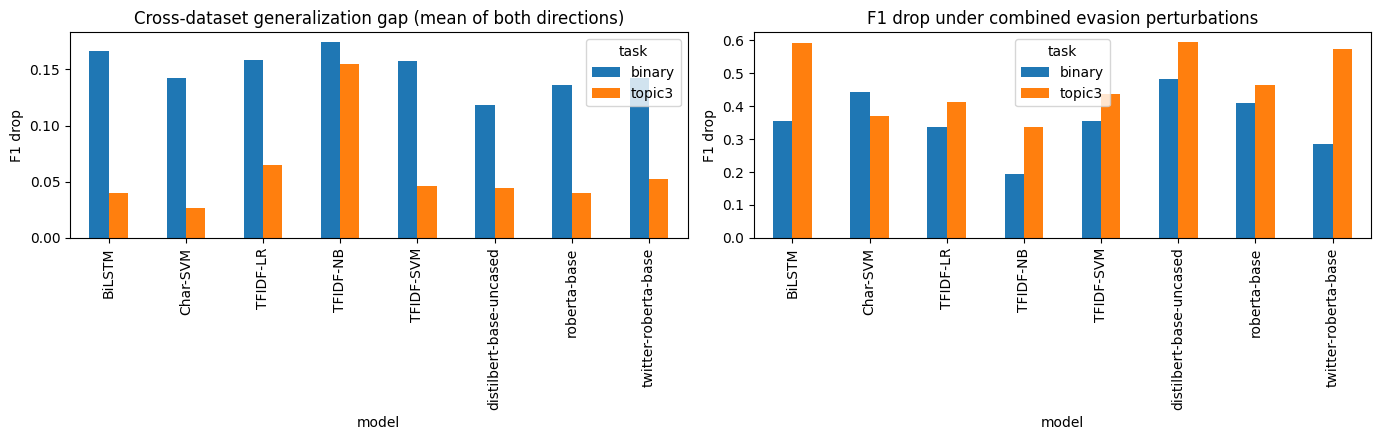

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
g = gap.groupby(['task', 'model']).generalization_gap.mean().unstack(0)
g.plot.bar(ax=ax[0]); ax[0].set_title('Cross-dataset generalization gap (mean of both directions)'); ax[0].set_ylabel('F1 drop')
r_ = rb[rb.perturbation == 'combined'].groupby(['task', 'model'])['drop'].mean().unstack(0)
r_.plot.bar(ax=ax[1]); ax[1].set_title('F1 drop under combined evasion perturbations'); ax[1].set_ylabel('F1 drop')
plt.tight_layout(); plt.savefig('summary.png', dpi=150); plt.show()

## How to read this for the paper
- A model with high in-domain F1 but a large gap is memorising dataset-specific cues, not learning cyberbullying.
- Compare Char-SVM against the word-level models and the transformers on the perturbation table: it shows whether sub-word information helps against evasion.
- `twitter-roberta-base` vs `roberta-base` isolates the effect of domain-specific pre-training.
- Results come from one seed. For the paper, rerun with 3 seeds (change `SEED`) and report mean ± std.